# 머신러닝입문 week05
## 선형회귀
### 이론

#### 선형회귀
* 선형회귀는 input, output이 모두 주어지는 지도학습이다.

#### 용어 정리
* x = input variable = feature = 특성값
* y = output variable = target = 목표값
* input data-output data 한 쌍은 ground truth라고 한다.

* (x<sup>(i)</sup>, y<sup>(i)</sup>) = i<sup>th</sup> training examples
  * → **괄호 주의!!**
* ex: (x<sup>(50)</sup>, y<sup>(50)</sup>) = (3210, 870)

* 예측값 = y-hat = ŷ

* f(x) = ax + b = wx + b

* w = weight = parameter

* b = bias = parameter


* w = 기울기 = slope

* b = y 절편 = intercept

#### Cost Function
1. w랑 b를 구하기 위해서 cost function을 만들었음
2. 임의로 w, b 값을 넣고 오차를 구함
3. cost function을 최소화 하는 w, b를 찾는다.

#### Cost Function = Mean Square Error(MSE) = J(w, b)
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

### 선형회귀 실습

In [ ]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0, 1000.0])

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(perch_length, perch_weight)

In [ ]:
x_train.shape # 1차 벡터

(42,)

In [ ]:
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

In [ ]:
x_train.shape # 2차 matrix로 변환

(42, 1)

In [11]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [12]:
lr.score(x_test, y_test)

0.9412054173245147

In [13]:
lr.predict([[50]])

array([1201.97378112])

In [ ]:
lr.coef_, lr.intercept_ # x값(coefficient 계수), b값(intercept 절편)

(array([36.60288223]), np.float64(-628.1703303565873))

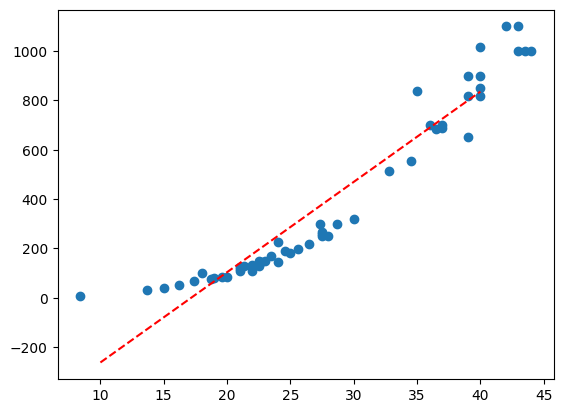

In [19]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.plot([10, 40], [lr.coef_ * 10 + lr.intercept_, lr.coef_ * 40 + lr.intercept_], 'r--')
plt.show()

### Pandas

In [20]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 7.9 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 60.6 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 38.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

dc = {'size': [65, 95, 65, 55, 80], 'nofroom': [3, 1, 2, 3, 5], 'price': [40, 80, 30, 80, 100]}
dc

{'size': [65, 95, 65, 55, 80],
 'nofroom': [3, 1, 2, 3, 5],
 'price': [40, 80, 30, 80, 100]}

In [25]:
df = pd.DataFrame(dc)
df

,size,nofroom,price
0,65,3,40
1,95,1,80
2,65,2,30
3,55,3,80
4,80,5,100


In [27]:
df.columns

Index(['size', 'nofroom', 'price'], dtype='object')

In [28]:
df['size']

0    65
1    95
2    65
3    55
4    80
Name: size, dtype: int64

In [32]:
df[['size', 'nofroom']]

,size,nofroom
0,65,3
1,95,1
2,65,2
3,55,3
4,80,5


In [33]:
df.size

15

In [34]:
df.nofroom

0    3
1    1
2    2
3    3
4    5
Name: nofroom, dtype: int64

In [35]:
df.columns = ['sizes', 'room', 'price']
df

,sizes,room,price
0,65,3,40
1,95,1,80
2,65,2,30
3,55,3,80
4,80,5,100


In [36]:
df.sizes

0    65
1    95
2    65
3    55
4    80
Name: sizes, dtype: int64

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/fifa25.csv')
df

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16156,16156,16156,17717,Engson Singh,47,31,45,47,52,34,...,India,ISL,Mohun Bagan SG,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16157,16157,16157,17717,Ousmane Sylla,47,67,38,46,45,40,...,Senegal,MLS,Houston Dynamo,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16158,16158,16158,17717,Wei Feng,47,57,47,38,50,43,...,China PR,CSL,Changchun Yatai,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16159,16159,16159,17717,Won Hui Do,47,66,35,46,46,41,...,Korea Republic,K League 1,Jeju United,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16161 entries, 0 to 16160
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0.1           16161 non-null  int64  
 1   Unnamed: 0             16161 non-null  int64  
 2   Rank                   16161 non-null  int64  
 3   Name                   16161 non-null  object 
 4   OVR                    16161 non-null  int64  
 5   PAC                    16161 non-null  int64  
 6   SHO                    16161 non-null  int64  
 7   PAS                    16161 non-null  int64  
 8   DRI                    16161 non-null  int64  
 9   DEF                    16161 non-null  int64  
 10  PHY                    16161 non-null  int64  
 11  Acceleration           16161 non-null  int64  
 12  Sprint Speed           16161 non-null  int64  
 13  Positioning            16161 non-null  int64  
 14  Finishing              16161 non-null  int64  
 15  Sh